In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
print("Project root added to sys.path")

Project root added to sys.path


In [2]:
import torch
import torch.nn 
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

from clients.federated_training import federated_training
from utils.data_partition import dirichlet_partition


torch.manual_seed(42)
np.random.seed(42)

In [3]:
import os

# Create results directory in the notebook directory
os.makedirs("results", exist_ok=True)
print("Results directory created at:", os.path.abspath("results"))

Results directory created at: c:\Users\la7tim\Desktop\Internship\FedTinyProp\notebooks\results


In [4]:

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    
    
trainset = datasets.MNIST('./data', train=True, download=True, transform=transform)
testset = datasets.MNIST('./data', train=False, transform=transform)
    
    

print(f"Training set size: {len(trainset)}")
print(f"Test set size: {len(testset)}")
print(f"Number of classes: {len(trainset.classes)}")

Training set size: 60000
Test set size: 10000
Number of classes: 10


In [5]:
num_clients = 5
partitions = {
    "IID":   dirichlet_partition(trainset, num_clients=num_clients, alpha=0.01),
}


c:\Users\la7tim\Desktop\Internship\FedTinyProp\utils\data_partition.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  labels = np.array(dataset.targets)



=== Partition Statistics for MNIST ===

IID Partition:
Total samples: 60000

Per-client distribution:
Client 0: 18057 samples (30.09%)
Client 1: 11340 samples (18.90%)
Client 2: 12593 samples (20.99%)
Client 3: 12076 samples (20.13%)
Client 4: 5934 samples (9.89%)
[Debug] Number of classes: 10
[Debug] Number of clients: 5
[Debug] Processing client 0 with 18057 samples
[Debug] Client 0 has 18057 valid targets
[Debug] Client 0 class counts: [1.000e+00 1.000e+00 5.953e+03 1.000e+00 5.837e+03 1.000e+00 1.000e+00
 6.260e+03 1.000e+00 1.000e+00]
[Debug] Processing client 1 with 11340 samples
[Debug] Client 1 has 11340 valid targets
[Debug] Client 1 class counts: [1.000e+00 1.000e+00 1.000e+00 3.000e+00 1.000e+00 5.417e+03 5.913e+03
 1.000e+00 1.000e+00 1.000e+00]
[Debug] Processing client 2 with 12593 samples
[Debug] Client 2 has 12593 valid targets
[Debug] Client 2 class counts: [1.000e+00 6.738e+03 1.000e+00 1.000e+00 2.000e+00 1.000e+00 1.000e+00
 1.000e+00 5.846e+03 1.000e+00]
[Debug] P

c:\Users\la7tim\Desktop\Internship\FedTinyProp\utils\partitions_visualization.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(partitions[0].dataset.targets)


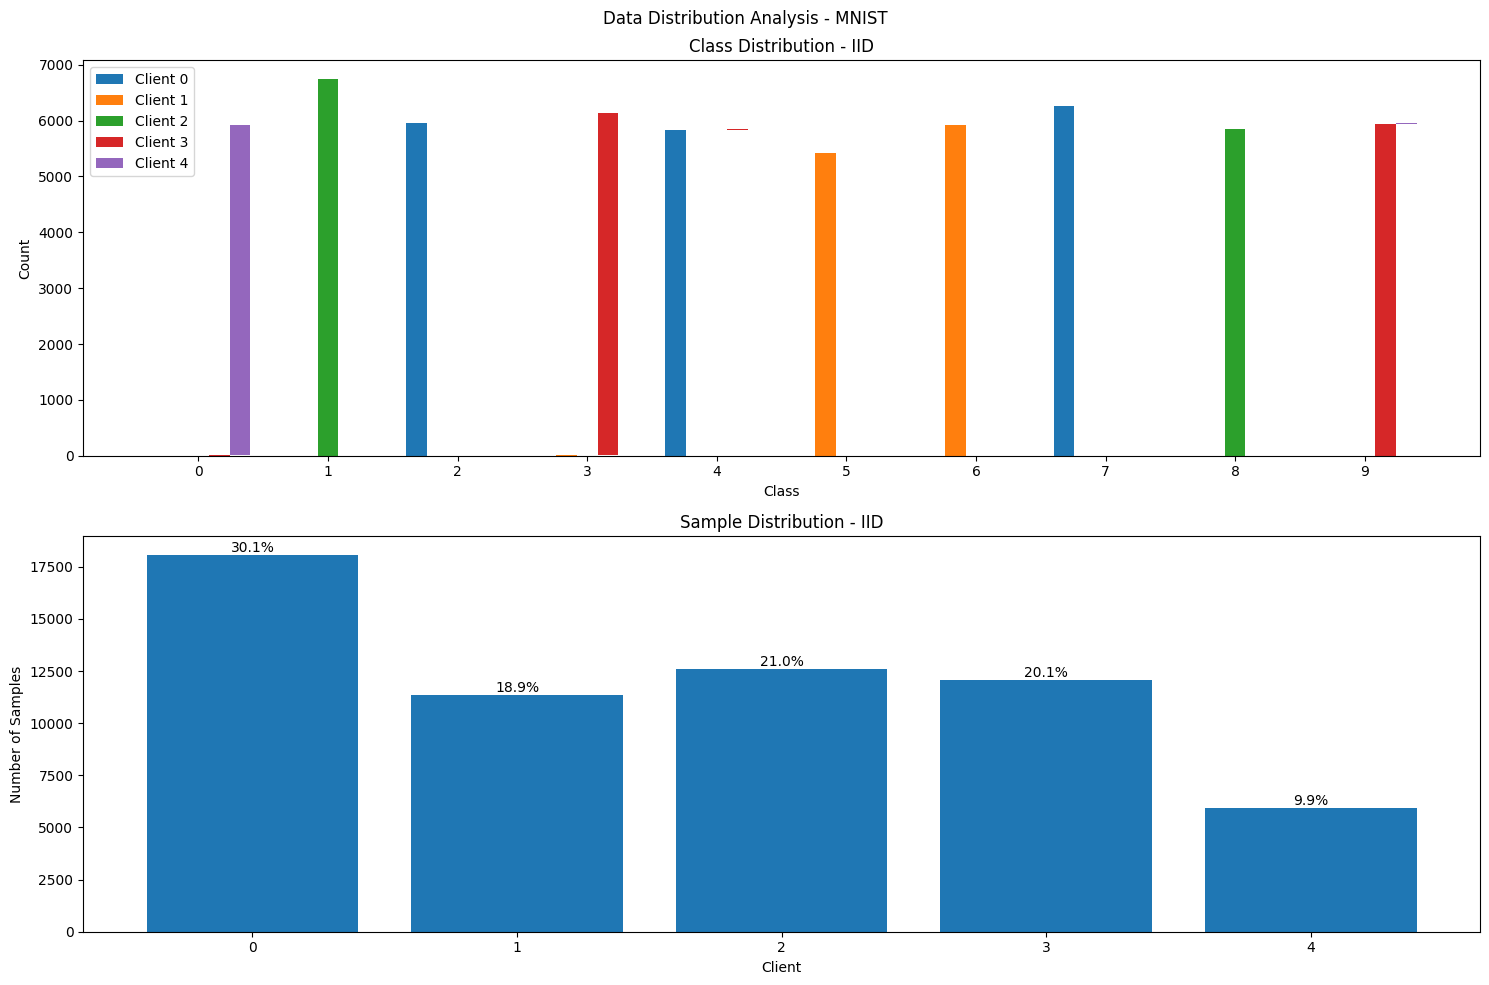

In [6]:
from utils.partitions_visualization import print_partition_stats, plot_data_distribution

# Print detailed statistics
print_partition_stats(partitions, "MNIST")

# Create comprehensive visualization
fig = plot_data_distribution(partitions, "MNIST")
plt.show()

In [7]:
from models.config import get_tinyprop_config

config = get_tinyprop_config("mnist")
config['quantization_bits'] = 8  # Explicit for clarity

print("\nModel Configuration:")
for key, value in config.items():
    print(f"{key}: {value}")

tinyprop_params = config["tinyprop_params"]
print("\nTinyProp Parameters:")
print(f"S_min: {tinyprop_params.S_min}")
print(f"S_max: {tinyprop_params.S_max}")
print(f"zeta: {tinyprop_params.zeta}")
print(f"number_of_layers: {tinyprop_params.number_of_layers}")



Model Configuration:
tinyprop_params: <models.tinyProp.TinyPropParams object at 0x000002471EA44590>
optimizer: {'type': 'sgd', 'lr': 0.0005, 'momentum': 0.7, 'weight_decay': 0.0001}
lr_scheduler: {'type': 'cosine', 'T_max': 100, 'eta_min': 1e-05, 'warmup_epochs': 5, 'warmup_start_lr': 1e-05}
gradient_clip: 1.0
batch_size: 32
num_epochs: 1
label_smoothing: 0.1
quantization: {'bits': 8, 'enabled': True, 'adaptive': True, 'min_bits': 4, 'max_bits': 16, 'layer_specific': True, 'error_threshold': 0.01, 'momentum': 0.9}
quantization_bits: 8

TinyProp Parameters:
S_min: 0.5
S_max: 0.95
zeta: 0.5
number_of_layers: 4


In [8]:
from clients.aggregators import sparse_fedavg_aggregate
def train_and_analyze_partition(partition_name, client_datasets, tinyprop_params):
    print(f"\nTraining on partition: {partition_name.upper()}")
    
    # Get base config
    config = get_tinyprop_config('mnist')
    
    # Run training
    model, metrics = federated_training(
        client_datasets=client_datasets,
        model_name='mnist',
        testset=testset,
        tinyprop_params=tinyprop_params,
        aggregator_fn=sparse_fedavg_aggregate,
        rounds=100,
        device="cuda" if torch.cuda.is_available() else "cpu",
        local_epochs=1,
        early_stopping_patience=100,
        early_stopping_delta=0.001,
        csv_log_path=f'results/mnist_metrics.csv',  # Single CSV file for all partitions
        initial_sparsity=tinyprop_params.S_min,
        target_sparsity=tinyprop_params.S_max,
        energy_budget=1000,
        save_dir='results',
        save_interval=1,
        use_dense_baseline=False,
        use_fedprox= False,
        fedprox_mu= 0.01,
        use_rigl= True,
        rigl_initial_sparsity= 0.5,
        rigl_target_sparsity= 0.95,
        rigl_update_interval= 100,
        rigl_final_update_epoch= 100,
    )
    
    # Print summary statistics
    print(f"\nTraining Summary for {partition_name.upper()}:")
    print(f"Final Accuracy: {metrics['accuracy'][-1]:.4f}")
    print(f"Average Sparsity: {np.mean(metrics['sparsity']):.4f}")
    print(f"Average Compression Ratio: {np.mean(metrics['compression_ratio']):.4f}")
    print(f"Average Effective Compute Ratio: {np.mean(metrics['effective_compute_ratio']):.4f}")
    print(f"Total Communication Cost: {metrics['communication'][-1]/1024:.2f} KB")
    print(f"Total Memory Saved: {metrics['memory_saved'][-1]:.2f} MB")
    
    return model, metrics

# Run training for each partition
partition_results = {}
for strategy_name, client_datasets in partitions.items():
    print(f"\nStarting training for {strategy_name.upper()} partition...")
    try:
        model, metrics = train_and_analyze_partition(strategy_name, client_datasets, tinyprop_params)
        partition_results[strategy_name] = {
            'model': model,
            'metrics': metrics
        }
        print(f"Completed training for {strategy_name.upper()}")
    except Exception as e:
        print(f"Error in {strategy_name.upper()}: {str(e)}")
        continue


Starting training for IID partition...

Training on partition: IID

[Training Debug] Initializing clients...
[Training Debug] Client 0 initialized with 18057 samples
[Training Debug] Client 1 initialized with 11340 samples
[Training Debug] Client 2 initialized with 12593 samples
[Training Debug] Client 3 initialized with 12076 samples
[Training Debug] Client 4 initialized with 5934 samples

Round 1/100

[Training Debug] Training client 0

[Training Debug] Training client 1

[Training Debug] Training client 2

[Training Debug] Training client 3

[Training Debug] Training client 4

[Server Debug] Starting aggregation of client updates...

[Server Debug] Aggregation Statistics:
Total clients processed: 5
Parameters skipped: 0
Parameters updated: 40/1625866
Dense updates: 0
Sparse updates: 40
Model size: 6351.04KB
Total download: 31755.20KB
Total upload: 31733.71KB
Total communication: 63488.91KB
Compression ratio: 1.00x

Per-layer communication:
  conv1.weight: 4.23KB
  conv1.bias: 0.41K